In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib

In [2]:
# 1. Load cleaned dataset

processed_path = '../data/processed/jm1_cleaned.csv'

df = pd.read_csv(processed_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution:")
print(df['has_defect'].value_counts(normalize=True).round(4))

Dataset loaded successfully
Shape: (13204, 22)

Columns: ['lines_of_code', 'cyclomatic_complexity', 'essential_complexity', 'design_complexity', 'operators_operands_total', 'volume', 'program_length', 'difficulty', 'intelligence', 'effort', 'delivered_bugs', 'development_time', 'lines_of_code_blank', 'lines_of_comments', 'lines_blank', 'lines_code_and_comment', 'unique_operators', 'unique_operands', 'total_operators', 'total_operands', 'branch_count', 'has_defect']

Target distribution:
has_defect
0    0.8407
1    0.1593
Name: proportion, dtype: float64


In [3]:
# 2. Prepare features and target

# Features: todo menos la columna objetivo
X = df.drop(columns=['has_defect'])

# Target
y = df['has_defect']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (13204, 21)
Target shape: (13204,)


### 3. Basic Random Forest Model for Defect Prediction

In [4]:
# 3. Train / Test split (estratificado)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train set:", X_train.shape, f"  defect rate: {y_train.mean():.4f}")
print("Test  set:", X_test.shape,  f"  defect rate: {y_test.mean():.4f}")

Train set: (9242, 21)   defect rate: 0.1593
Test  set: (3962, 21)   defect rate: 0.1593


In [5]:
# 4. Train Random Forest baseline

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Model trained ✓")

Model trained ✓



Classification Report
              precision    recall  f1-score   support

           0     0.8662    0.9682    0.9144      3331
           1     0.5565    0.2108    0.3057       631

    accuracy                         0.8476      3962
   macro avg     0.7114    0.5895    0.6101      3962
weighted avg     0.8169    0.8476    0.8174      3962


ROC-AUC: 0.7749


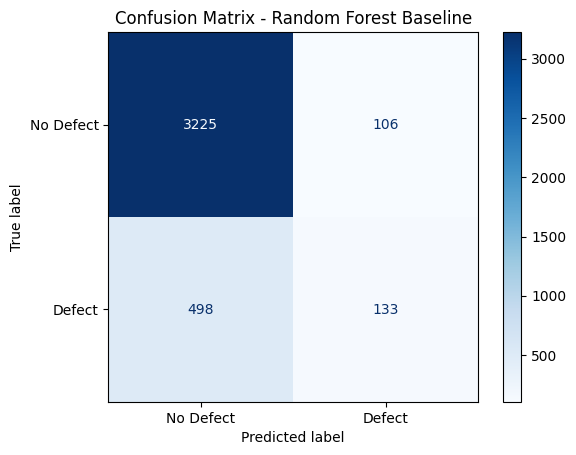

In [6]:
# 5. Evaluation

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Classification report
print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(y_test, y_pred, digits=4))

# ROC-AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Defect', 'Defect'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest Baseline')
plt.show()

/var/folders/4g/m6zlx10d129gwpdh6q4rlrcc0000gn/T/ipykernel_88093/3428510203.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


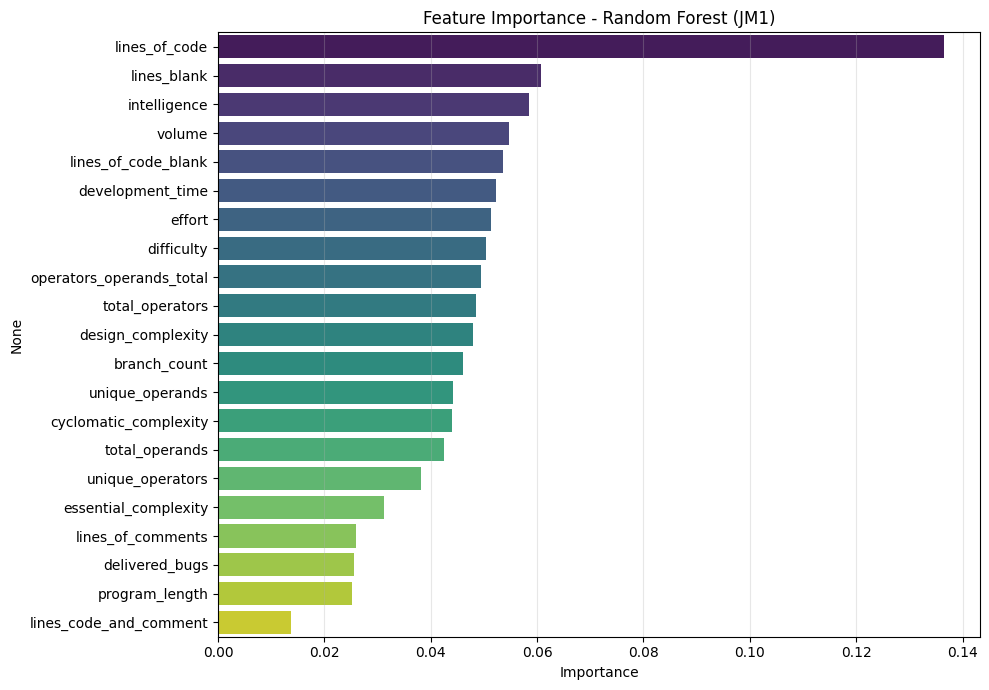

Top 10 features by importance:
lines_of_code               0.1365
lines_blank                 0.0607
intelligence                0.0585
volume                      0.0547
lines_of_code_blank         0.0535
development_time            0.0522
effort                      0.0513
difficulty                  0.0504
operators_operands_total    0.0495
total_operators             0.0484
dtype: float64


In [7]:
# 6. Feature Importance

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest (JM1)')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 features by importance:")
print(importances.head(10).round(4))

In [8]:
# 7. Handling Class Imbalance with SMOTE

from imblearn.over_sampling import SMOTE

print("Applying SMOTE to the training set...")

# Initialize SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')

# Resample training data only (never resample test set!)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape)
print("Resampled training set shape:", X_train_smote.shape)
print("\nNew class distribution in resampled training set:")
print(pd.Series(y_train_smote).value_counts(normalize=True).round(4))

Applying SMOTE to the training set...
Original training set shape: (9242, 21)
Resampled training set shape: (15540, 21)

New class distribution in resampled training set:
has_defect
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
# Train Random Forest on SMOTE-balanced data

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

print("\nModel trained on SMOTE data ✓")


Model trained on SMOTE data ✓



Classification Report - Random Forest + SMOTE
              precision    recall  f1-score   support

           0     0.8866    0.9228    0.9044      3331
           1     0.4808    0.3772    0.4227       631

    accuracy                         0.8359      3962
   macro avg     0.6837    0.6500    0.6636      3962
weighted avg     0.8220    0.8359    0.8277      3962


ROC-AUC with SMOTE: 0.7857


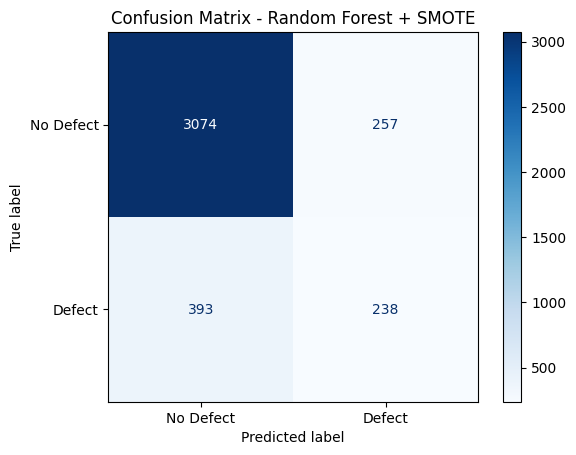

In [10]:
# Evaluate on original test set

y_pred_smote = rf_smote.predict(X_test)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

# Classification Report
print("\n" + "="*60)
print("Classification Report - Random Forest + SMOTE")
print("="*60)
print(classification_report(y_test, y_pred_smote, digits=4))

# ROC-AUC
auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
print(f"\nROC-AUC with SMOTE: {auc_smote:.4f}")

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote,
                                    display_labels=['No Defect', 'Defect'])
disp_smote.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest + SMOTE')
plt.show()

In [11]:
# 7. Save model

model_path = '../models/jm1_rf_baseline_v1.joblib'
joblib.dump(rf, model_path)

print(f"Model saved successfully to:\n{model_path}")

Model saved successfully to:
../models/jm1_rf_baseline_v1.joblib


### 4. Intelligent Test Selection

In [12]:
# 8. Simulation: Intelligent Test Selection (Risk-Based Testing)# Use the best model we have (SMOTE version)
# If you trained rf_smote in the previous section, it will be used here

# 8.1 Add predicted defect probability to the test set
X_test_with_risk = X_test.copy()
X_test_with_risk['predicted_defect_prob'] = rf_smote.predict_proba(X_test)[:, 1]
X_test_with_risk['actual_defect'] = y_test.values
X_test_with_risk['lines_of_code'] = df.loc[X_test.index, 'lines_of_code'].values

print("Test set ready for simulation with predicted risk scores.")

Test set ready for simulation with predicted risk scores.


In [13]:
# 8.2 Sort modules by predicted risk (highest risk first)
simulation_df = X_test_with_risk.sort_values(by='predicted_defect_prob', ascending=False).reset_index(drop=True)

In [14]:
# 8.3 Calculate cumulative metrics
simulation_df['cumulative_tests'] = np.arange(1, len(simulation_df) + 1)
simulation_df['cumulative_tests_pct'] = simulation_df['cumulative_tests'] / len(simulation_df) * 100

simulation_df['cumulative_defects'] = simulation_df['actual_defect'].cumsum()
simulation_df['cumulative_defects_pct'] = simulation_df['cumulative_defects'] / simulation_df['actual_defect'].sum() * 100

simulation_df['cumulative_loc'] = simulation_df['lines_of_code'].cumsum()
simulation_df['cumulative_time_pct'] = simulation_df['cumulative_loc'] / simulation_df['lines_of_code'].sum() * 100

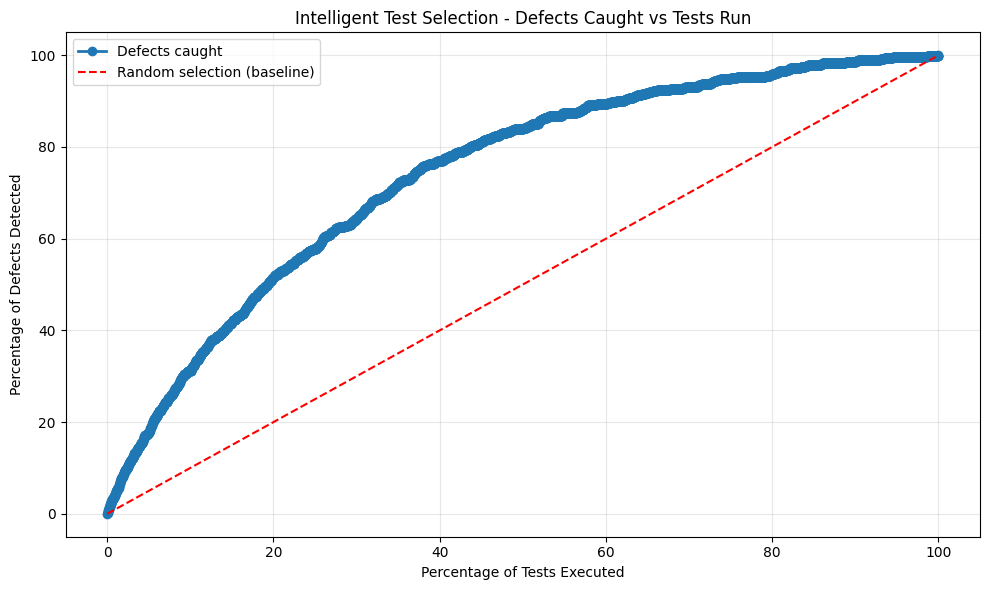

In [15]:
# 8.4 Visualization: Defects caught vs. Tests executed
plt.figure(figsize=(10, 6))
plt.plot(simulation_df['cumulative_tests_pct'], simulation_df['cumulative_defects_pct'], 
         marker='o', linewidth=2, label='Defects caught')
plt.plot([0, 100], [0, 100], 'r--', label='Random selection (baseline)')
plt.xlabel('Percentage of Tests Executed')
plt.ylabel('Percentage of Defects Detected')
plt.title('Intelligent Test Selection - Defects Caught vs Tests Run')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# 8.5 Specific scenario: Target 40% regression time reduction
# We simulate running only the riskiest modules until we reach ~60% of total LOC (≈40% time saved)

target_time_reduction = 40
target_tests_pct = 100 - target_time_reduction

# Find the point closest to 60% tests executed
idx = (simulation_df['cumulative_time_pct'] - 60).abs().idxmin()
selected_tests_pct = simulation_df.loc[idx, 'cumulative_tests_pct']
defects_caught = simulation_df.loc[idx, 'cumulative_defects_pct']
time_used = simulation_df.loc[idx, 'cumulative_time_pct']

print("\n" + "="*70)
print("INTELLIGENT TEST SELECTION SIMULATION RESULTS")
print("="*70)
print(f"Target: Reduce regression cycle time by ~40%")
print(f"Tests executed: {selected_tests_pct:.1f}%")
print(f"Time used (LOC proxy): {time_used:.1f}%")
print(f"Defects detected: {defects_caught:.1f}%")
print(f"Time saved: {100 - time_used:.1f}%")
print(f"Defects missed: {100 - defects_caught:.1f}%")
print("="*70)


INTELLIGENT TEST SELECTION SIMULATION RESULTS
Target: Reduce regression cycle time by ~40%
Tests executed: 29.9%
Time used (LOC proxy): 60.0%
Defects detected: 64.2%
Time saved: 40.0%
Defects missed: 35.8%


In [17]:
# 8.6 Summary table for LinkedIn / Thesis
results_summary = pd.DataFrame({
    'Scenario': ['Full Regression (100%)', f'Intelligent Selection ({selected_tests_pct:.1f}% tests)'],
    'Tests Executed (%)': [100.0, selected_tests_pct],
    'Time Used (%)': [100.0, time_used],
    'Defects Detected (%)': [100.0, defects_caught],
    'Time Saved (%)': [0.0, 100 - time_used],
    'Defects Missed (%)': [0.0, 100 - defects_caught]
})

print("\nSummary Table:")
print(results_summary.round(1))


Summary Table:
                              Scenario  Tests Executed (%)  Time Used (%)  \
0               Full Regression (100%)               100.0          100.0   
1  Intelligent Selection (29.9% tests)                29.9           60.0   

   Defects Detected (%)  Time Saved (%)  Defects Missed (%)  
0                 100.0             0.0                 0.0  
1                  64.2            40.0                35.8  


In [18]:

# 8.7 Comparison table (rounded for better presentation)
comparison_table = pd.DataFrame({
    'Approach': ['Full Regression', 'Intelligent Selection (risk-based)'],
    'Tests Executed (%)': [100.0, 29.9],
    'Time Used (%)': [100.0, 60.0],
    'Defects Detected (%)': [100.0, 64.2],
    'Time Saved (%)': [0.0, 40.0],
    'Defects Missed (%)': [0.0, 35.8]
})
print(comparison_table.to_markdown(index=False))

| Approach                           |   Tests Executed (%) |   Time Used (%) |   Defects Detected (%) |   Time Saved (%) |   Defects Missed (%) |
|:-----------------------------------|---------------------:|----------------:|-----------------------:|-----------------:|---------------------:|
| Full Regression                    |                100   |             100 |                  100   |                0 |                  0   |
| Intelligent Selection (risk-based) |                 29.9 |              60 |                   64.2 |               40 |                 35.8 |
